In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from graph_state import AssistantState, DepartmentRoute

In [3]:
system_prompt = """
You are the campus assistant's query-routing system.

Your only task is to route the user's query to the correct department.

Available departments:
- IT: accounts, passwords, Wi-Fi, software, computers, technical issues
- HR: employment, leave, payroll, benefits, workplace policies
- Fees: tuition, invoices, payments, refunds, financial aid
- Facilities: buildings, rooms, maintenance, transport, security, access
- Admissions: applications, enrollment, eligibility, deadlines
- Academics: courses, grades, exams, schedules, academic policies
- General: clear questions that do not belong to another department

Routing rules:
1. Route clear queries to the most appropriate department.
2. If one query clearly concerns multiple departments, include all relevant departments.
3. Route to "Human" only when you cannot understand the user's intent.
4. Do not route to "Human" just because the query is unusual or has low confidence.
5. Use "Human" for vague queries such as "Help me", unintelligible text,
   or queries with no understandable purpose.
6. Never answer the user's question.
7. Return data that matches the schema exactly.
"""

In [4]:
from graph import build_graph


In [5]:
agent = build_graph()


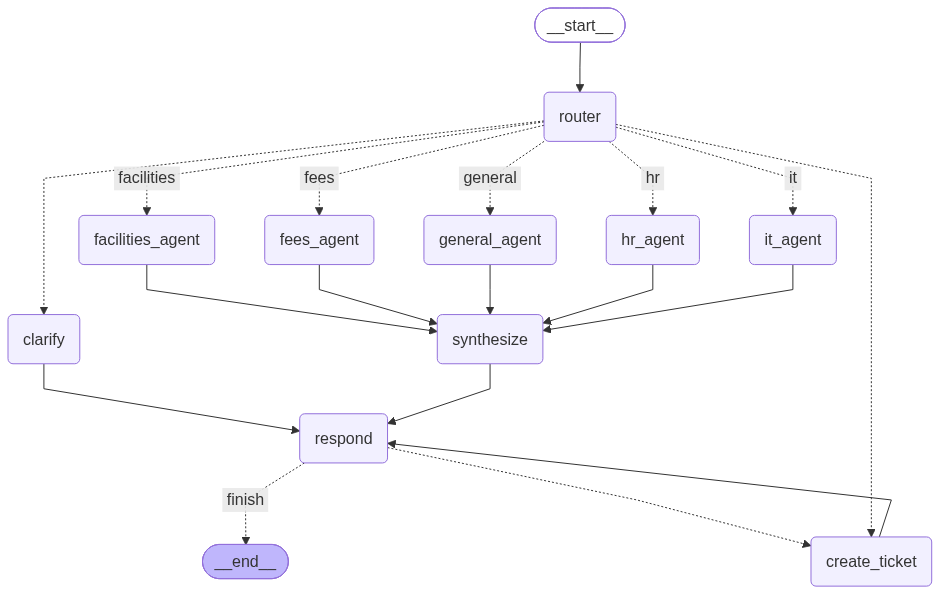

In [6]:
agent


In [7]:
chat_history = ""
user_query = "my wifi is not working"

In [8]:
messages = [
    SystemMessage(content=system_prompt),
    HumanMessage(
        content=f"""
Conversation history:
{chat_history}

User query:
{user_query}
"""
    )
]

In [9]:
initial_state = {
    "current_query": user_query,
}


In [10]:
config = {
    "configurable": {
        "thread_id": "student-demo-1",
    }
}
result = agent.invoke(initial_state, config=config)


/home/abhaychandra/projects/campus-one/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2534.49it/s]


In [11]:
print(result)

{'messages': [{'role': 'user', 'content': 'my wifi is not working'}, {'role': 'assistant', 'content': '1. Verify that Wi‑Fi is turned on on your device.\n2. Check that the date and time settings are correct.\n3. Connect to the correct SSID (e.g., **NBU‑Student**) using your up‑to‑date university credentials.\n4. If the connection still fails, forget the network and reconnect.\n5. If the issue continues—especially if multiple devices in the same location are affected—report the building, floor, room, and the affected device to Network Operations (or the Service Desk) for further investigation.'}], 'current_query': 'my wifi is not working', 'detected_domains': ['IT'], 'intent': 'IT', 'routing_confidence': 0.97, 'agent_response': 'First, make sure your device’s Wi‑Fi is turned on, the date and time are correct, you are connected to the correct SSID (e.g., NBU‑Student) and your university credentials are up‑to‑date. If the connection still fails, try forgetting the network and reconnecting

In [12]:
result["final_answer"]

'1. Verify that Wi‑Fi is turned on on your device.\n2. Check that the date and time settings are correct.\n3. Connect to the correct SSID (e.g., **NBU‑Student**) using your up‑to‑date university credentials.\n4. If the connection still fails, forget the network and reconnect.\n5. If the issue continues—especially if multiple devices in the same location are affected—report the building, floor, room, and the affected device to Network Operations (or the Service Desk) for further investigation.'

In [13]:
result["detected_domains"]

['IT']

In [14]:
from knowledge_retrieval import (
    FACILITIES_KNOWLEDGE_BASE,
    FINANCE_KNOWLEDGE_BASE,
    HR_KNOWLEDGE_BASE,
    IT_KNOWLEDGE_BASE,
    retrieve_documents,
)

collection_by_department = {
    "IT": IT_KNOWLEDGE_BASE,
    "HR": HR_KNOWLEDGE_BASE,
    "Fees": FINANCE_KNOWLEDGE_BASE,
    "Facilities": FACILITIES_KNOWLEDGE_BASE,
}

department = result.get("detected_domains", [None])[0]
collection_name = collection_by_department.get(department)

if collection_name is None:
    print(f"No PDF retrieval is used for department: {department or 'Unknown'}")
else:
    retrieved_documents = retrieve_documents(
        query=user_query,
        collection_name=collection_name,
        number_of_documents=4,
    )

    print(f"Retrieved {len(retrieved_documents)} documents from {collection_name}:\n")
    for index, document in enumerate(retrieved_documents, start=1):
        source = document.metadata.get("source", "Unknown document")
        page = document.metadata.get("page")
        page_label = f", page {page + 1}" if isinstance(page, int) else ""
        print(f"--- Document {index}: {source}{page_label} ---")
        print(document.page_content)
        print()

Retrieved 4 documents from it_knowledge:

--- Document 1: 01_IT_Services_Handbook_v3.pdf, page 4 ---
11. Service Request Procedures
Request
Required information
Approval
Application access
Application, role, reason
Application owner
Software request
Software, version, course/project
Software owner
VPN access
ID and internal service
Role-based
Shared folder access
Folder, role, reason
Folder owner
New classroom equipment
Room, equipment, date
Department + IT
Access is granted according to least-privilege principles. Approval for one system does not automatically grant access to
another system.
12. IT FAQ
Q: How do I reset my university password?
A: Use the Identity Portal if self-service recovery is available. Otherwise contact the Service Desk for identity verification.
Q: My Wi-Fi works in the library but not my hostel room. What should I report?
A: Report the building, floor, room and affected device. Location-specific failures help Network Operations identify
access-point problems.


In [15]:
user_query = "what should I do next?"
initial_state = {"current_query": user_query}
result = agent.invoke(initial_state, config=config)
print("messages retained:", len(result["messages"]))
print(result["final_answer"])


messages retained: 4
Please report the issue to Network Operations (or the Service Desk). Provide the building, floor, and room where the Wi‑Fi problem occurs, along with the device(s) affected, so they can investigate and resolve the connectivity problem.
